In [6]:
"""Import the model"""
import numpy as np
import sys
import os
import collections
import collections.abc

# --- FIXES DE COMPATIBILIDAD ---

# collections (madmom)
collections.MutableSequence = collections.abc.MutableSequence

# numpy (madmom)
if not hasattr(np, 'float'):
    np.float = float
if not hasattr(np, 'int'):
    np.int = int
if not hasattr(np, 'bool'):
    np.bool = bool

# tensorflow / keras
os.environ["TF_USE_LEGACY_KERAS"] = "True"

# --- PATH DEL PROYECTO ---
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, project_root)

print("Project root:", project_root)

# --- IMPORT DEL MODELO ---
from adtof.model.model import Model

model, hparams = Model.modelFactory(
    modelName="Frame_RNN",
    scenario="adtofAll",
    fold=0
)

assert "peakThreshold" in hparams
assert model.weightLoadedFlag

Project root: c:\Users\rsanc\Documents\MAGISTER EN ACUSTICA Y VIBRACIONES\SEMESTRE IV\Automatic-Drum-Transcription-with-Vibrations-main





In [7]:
"""Transcribe any audio file."""

# Change the paths according to your configuration
audioFiles = r"C:\Users\rsanc\Documents\Proyectos\Automatic-Drum-Transcription-with-Vibrations-main\audio files\Borivers - Stadium Rock Drum Fill_05 - 111 BPM.wav"
outputLocation = r"C:\Users\rsanc\Documents\Proyectos\Automatic-Drum-Transcription-with-Vibrations-main\audio output"
model.predictFolder(audioFiles, outputLocation, **hparams)


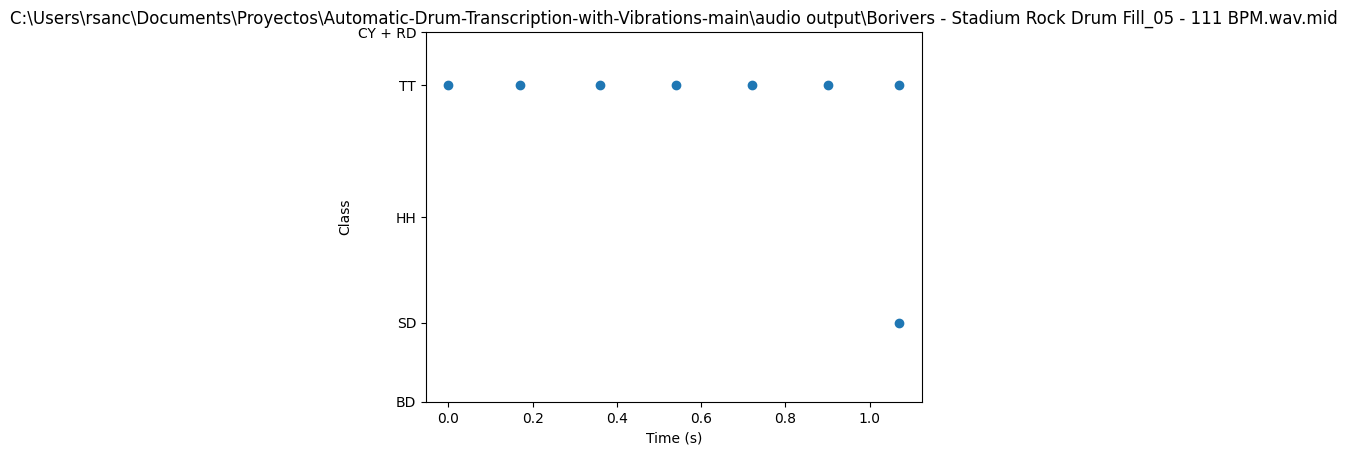

In [8]:
"""plot the estimated transcription"""
import pretty_midi
import glob
import matplotlib.pyplot as plt

for file in glob.glob(outputLocation+"/*.mid"):
    transcription = pretty_midi.PrettyMIDI(file)
    plt.scatter([note.start for note in transcription.instruments[0].notes], [note.pitch for note in transcription.instruments[0].notes])
    plt.yticks([35, 38, 42, 47, 49], ["BD", "SD", "HH", "TT", "CY + RD"])
    plt.title(file)
    plt.xlabel("Time (s)")
    plt.ylabel("Class")
    plt.show()
    break